# Statistics in Data Science

## Week 4: Hypothesis Testing & Statistical Analysis

In this notebook, we'll explore statistical tests and how to use them to make data-driven decisions.

### Key Questions:
1. Is the difference between groups significant or just random variation?
2. Are two variables related?
3. How confident are we in our conclusions?

---

## Import Libraries

In [2]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# Set random seed for reproducibility
np.random.seed(42)

print("Libraries loaded!")

Libraries loaded!


## 1. Descriptive Statistics

Understanding the basic characteristics of your data.

In [3]:
# Create sample employee data
data = {
    'Name': ['Alice', 'Bob', 'Charlie', 'David', 'Eve', 'Frank', 'Grace', 'Henry'],
    'Age': [25, 30, 28, 28, 35, 29, 26, 32],
    'Salary': [50000, 60000, 55000, 65000, 75000, 70000, 52000, 68000],
    'Department': ['Sales', 'IT', 'HR', 'Sales', 'IT', 'HR', 'IT', 'Sales']
}

df = pd.DataFrame(data)
print(df)

print("\n" + "="*50)
print("DESCRIPTIVE STATISTICS FOR SALARY")
print("="*50)
print(f"Mean: ${df['Salary'].mean():,.0f}")
print(f"Median: ${df['Salary'].median():,.0f}")
print(f"Std Dev: ${df['Salary'].std():,.0f}")
print(f"Min: ${df['Salary'].min():,.0f}")
print(f"Max: ${df['Salary'].max():,.0f}")
print(f"Range: ${df['Salary'].max() - df['Salary'].min():,.0f}")

      Name  Age  Salary Department
0    Alice   25   50000      Sales
1      Bob   30   60000         IT
2  Charlie   28   55000         HR
3    David   28   65000      Sales
4      Eve   35   75000         IT
5    Frank   29   70000         HR
6    Grace   26   52000         IT
7    Henry   32   68000      Sales

DESCRIPTIVE STATISTICS FOR SALARY
Mean: $61,875
Median: $62,500
Std Dev: $9,062
Min: $50,000
Max: $75,000
Range: $25,000


## 2. Probability Distributions

Understanding how data is distributed helps us choose appropriate statistical tests.

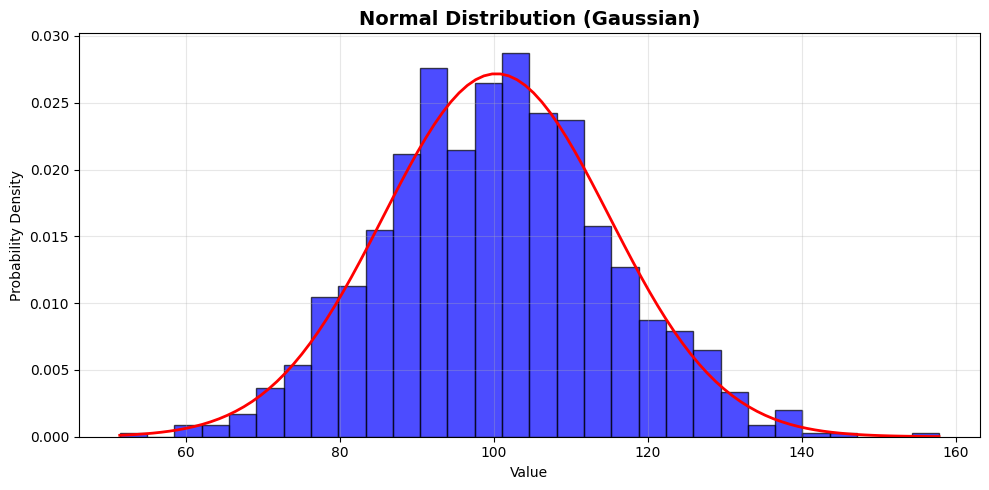

Mean: 100.29
Std Dev: 14.68


In [4]:
# Normal Distribution (Bell Curve)
# Many real-world phenomena follow normal distribution

# Generate sample data from normal distribution
normal_data = np.random.normal(loc=100, scale=15, size=1000)

# Plot histogram
plt.figure(figsize=(10, 5))
plt.hist(normal_data, bins=30, density=True, alpha=0.7, color='blue', edgecolor='black')

# Overlay normal distribution curve
x = np.linspace(normal_data.min(), normal_data.max(), 100)
plt.plot(x, stats.norm.pdf(x, normal_data.mean(), normal_data.std()), 'r-', linewidth=2)

plt.title('Normal Distribution (Gaussian)', fontsize=14, fontweight='bold')
plt.xlabel('Value')
plt.ylabel('Probability Density')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Mean: {normal_data.mean():.2f}")
print(f"Std Dev: {normal_data.std():.2f}")

## 3. Confidence Intervals

A range of values likely to contain the true population parameter.

In [5]:
# Calculate 95% Confidence Interval for mean salary
sample_mean = df['Salary'].mean()
sample_std = df['Salary'].std()
n = len(df)
se = sample_std / np.sqrt(n)  # Standard Error

# Critical value for 95% CI (t-distribution with n-1 df)
t_critical = stats.t.ppf(0.975, df=n-1)  # 0.975 for 2-tailed 95% CI

# Calculate CI
margin_of_error = t_critical * se
ci_lower = sample_mean - margin_of_error
ci_upper = sample_mean + margin_of_error

print("95% Confidence Interval for Mean Salary:")
print(f"Sample Mean: ${sample_mean:,.0f}")
print(f"Standard Error: ${se:,.0f}")
print(f"Margin of Error: ${margin_of_error:,.0f}")
print(f"\nCI: [${ci_lower:,.0f}, ${ci_upper:,.0f}]")
print(f"\nInterpretation: We are 95% confident the true population mean salary")
print(f"is between ${ci_lower:,.0f} and ${ci_upper:,.0f}")

95% Confidence Interval for Mean Salary:
Sample Mean: $61,875
Standard Error: $3,204
Margin of Error: $7,576

CI: [$54,299, $69,451]

Interpretation: We are 95% confident the true population mean salary
is between $54,299 and $69,451


## 4. Hypothesis Testing

Testing whether a claim about the data is true or false.

### One-Sample T-Test

Test if the mean of a group is different from a hypothesized value.
\begin{align}
H_0:& \mu = \mu_0 \text{ (null hypothesis)} \\
H_a:& \mu \neq \mu_0 \text{ (alternative hypothesis)}
\end{align}

In [6]:
# Question: Is the average salary significantly different from $65,000?
hypothesized_salary = 65000

t_stat, p_value = stats.ttest_1samp(df['Salary'], hypothesized_salary)

print("ONE-SAMPLE T-TEST")
print("="*50)
print(f"Null Hypothesis: Mean salary = ${hypothesized_salary:,}")
print(f"Alternative: Mean salary ≠ ${hypothesized_salary:,}")
print(f"\nSample mean: ${df['Salary'].mean():,.0f}")
print(f"Test statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"Significance level (α): 0.05")
print(f"\nConclusion:")
if p_value < 0.05:
    print(f"✓ REJECT null hypothesis (p = {p_value:.4f} < 0.05)")
    print(f"  The mean salary IS significantly different from ${hypothesized_salary:,}")
else:
    print(f"✗ FAIL TO REJECT null hypothesis (p = {p_value:.4f} ≥ 0.05)")
    print(f"  The mean salary is NOT significantly different from ${hypothesized_salary:,}")

ONE-SAMPLE T-TEST
Null Hypothesis: Mean salary = $65,000
Alternative: Mean salary ≠ $65,000

Sample mean: $61,875
Test statistic: -0.9753
P-value: 0.3619
Significance level (α): 0.05

Conclusion:
✗ FAIL TO REJECT null hypothesis (p = 0.3619 ≥ 0.05)
  The mean salary is NOT significantly different from $65,000


### Two-Sample T-Test

Test if the means of two groups are significantly different.

In [7]:
# Question: Do IT employees earn significantly more than HR employees?
it_salaries = df[df['Department'] == 'IT']['Salary']
hr_salaries = df[df['Department'] == 'HR']['Salary']

t_stat, p_value = stats.ttest_ind(it_salaries, hr_salaries)

print("TWO-SAMPLE T-TEST")
print("="*50)
print(f"H0: μ_IT = μ_HR (mean salaries are equal)")
print(f"Ha: μ_IT ≠ μ_HR (mean salaries are different)")
print(f"\nIT Department (n={len(it_salaries)}):")
print(f"   Mean: ${it_salaries.mean():,.0f}, Std: ${it_salaries.std():,.0f}")
print(f"\nHR Department (n={len(hr_salaries)}):")
print(f"   Mean: ${hr_salaries.mean():,.0f}, Std: ${hr_salaries.std():,.0f}")
print(f"\nTest statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"\nConclusion:")
if p_value < 0.05:
    print(f"✓ REJECT null hypothesis (p = {p_value:.4f} < 0.05)")
    print(f"  There IS a significant difference between IT and HR salaries")
else:
    print(f"✗ FAIL TO REJECT null hypothesis (p = {p_value:.4f} ≥ 0.05)")
    print(f"  There is NO significant difference between IT and HR salaries")

TWO-SAMPLE T-TEST
H0: μ_IT = μ_HR (mean salaries are equal)
Ha: μ_IT ≠ μ_HR (mean salaries are different)

IT Department (n=3):
   Mean: $62,333, Std: $11,676

HR Department (n=2):
   Mean: $62,500, Std: $10,607

Test statistic: -0.0161
P-value: 0.9882

Conclusion:
✗ FAIL TO REJECT null hypothesis (p = 0.9882 ≥ 0.05)
  There is NO significant difference between IT and HR salaries


## 5. Correlation Analysis

Measure the strength and direction of relationship between two variables.

PEARSON CORRELATION TEST
H0: ρ = 0 (no correlation between variables)
Ha: ρ ≠ 0 (there is correlation)

Correlation coefficient (r): 0.9080
P-value: 0.0018

Interpretation:
There is a strong positive correlation: 0.9080
✓ This correlation is statistically significant (p = 0.0018)


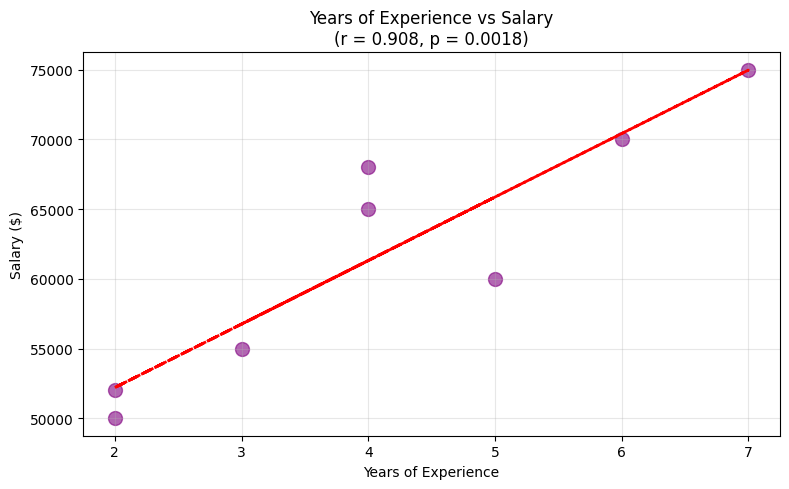

In [8]:
# Create additional data for correlation
years_experience = [2, 5, 3, 4, 7, 6, 2, 4]
df['Years_Experience'] = years_experience

# Pearson Correlation
correlation, p_value = stats.pearsonr(df['Years_Experience'], df['Salary'])

print("PEARSON CORRELATION TEST")
print("="*50)
print(f"H0: ρ = 0 (no correlation between variables)")
print(f"Ha: ρ ≠ 0 (there is correlation)")
print(f"\nCorrelation coefficient (r): {correlation:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"\nInterpretation:")
if abs(correlation) < 0.3:
    strength = "weak"
elif abs(correlation) < 0.7:
    strength = "moderate"
else:
    strength = "strong"

direction = "positive" if correlation > 0 else "negative"
print(f"There is a {strength} {direction} correlation: {correlation:.4f}")

if p_value < 0.05:
    print(f"✓ This correlation is statistically significant (p = {p_value:.4f})")
else:
    print(f"✗ This correlation is NOT statistically significant (p = {p_value:.4f})")

# Visualize
plt.figure(figsize=(8, 5))
plt.scatter(df['Years_Experience'], df['Salary'], s=100, alpha=0.6, color='purple')
z = np.polyfit(df['Years_Experience'], df['Salary'], 1)
p = np.poly1d(z)
plt.plot(df['Years_Experience'], p(df['Years_Experience']), "r--", linewidth=2)
plt.title(f'Years of Experience vs Salary\n(r = {correlation:.3f}, p = {p_value:.4f})', fontsize=12)
plt.xlabel('Years of Experience')
plt.ylabel('Salary ($)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Chi-Square Test

Test independence between categorical variables.

In [9]:
# Question: Is there an association between department and salary level?
# First, create salary categories
df['Salary_Level'] = pd.cut(df['Salary'], bins=[0, 60000, 100000], labels=['Low', 'High'])

# Create contingency table
contingency_table = pd.crosstab(df['Department'], df['Salary_Level'])
print("CONTINGENCY TABLE")
print(contingency_table)

# Chi-square test
chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)

print("\nCHI-SQUARE TEST OF INDEPENDENCE")
print("="*50)
print(f"H0: Department and Salary Level are independent")
print(f"Ha: There is an association between them")
print(f"\nChi-square statistic: {chi2:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"Degrees of freedom: {dof}")
print(f"\nConclusion:")
if p_value < 0.05:
    print(f"✓ REJECT null hypothesis (p = {p_value:.4f} < 0.05)")
    print(f"  There IS an association between Department and Salary Level")
else:
    print(f"✗ FAIL TO REJECT null hypothesis (p = {p_value:.4f} ≥ 0.05)")
    print(f"  There is NO significant association")

CONTINGENCY TABLE
Salary_Level  Low  High
Department             
HR              1     1
IT              2     1
Sales           1     2

CHI-SQUARE TEST OF INDEPENDENCE
H0: Department and Salary Level are independent
Ha: There is an association between them

Chi-square statistic: 0.6667
P-value: 0.7165
Degrees of freedom: 2

Conclusion:
✗ FAIL TO REJECT null hypothesis (p = 0.7165 ≥ 0.05)
  There is NO significant association


## 7. Effect Size

The practical significance of a result, not just statistical significance.

In [10]:
# Calculate Cohen's d (effect size for t-test)
# Measures how many standard deviations apart two means are

it_salaries = df[df['Department'] == 'IT']['Salary']
hr_salaries = df[df['Department'] == 'HR']['Salary']

# Pooled standard deviation
n1, n2 = len(it_salaries), len(hr_salaries)
s1, s2 = it_salaries.std(), hr_salaries.std()
pooled_std = np.sqrt(((n1-1)*s1**2 + (n2-1)*s2**2) / (n1 + n2 - 2))

# Cohen's d
cohens_d = (it_salaries.mean() - hr_salaries.mean()) / pooled_std

print("EFFECT SIZE (Cohen's d)")
print("="*50)
print(f"Cohen's d: {cohens_d:.4f}")
print(f"\nInterpretation:")
if abs(cohens_d) < 0.2:
    effect = "negligible"
elif abs(cohens_d) < 0.5:
    effect = "small"
elif abs(cohens_d) < 0.8:
    effect = "medium"
else:
    effect = "large"

print(f"{effect.upper()} effect size")
print(f"\nNote: A small p-value doesn't always mean a large effect size!")

EFFECT SIZE (Cohen's d)
Cohen's d: -0.0147

Interpretation:
NEGLIGIBLE effect size

Note: A small p-value doesn't always mean a large effect size!


## Summary: Statistical Testing Framework

### Steps to Follow:
1. **State Hypotheses**: Null (H0) and Alternative (Ha)
2. **Choose Test**: Based on data type and research question
3. **Calculate Test Statistic**: t, χ², correlation, etc.
4. **Determine P-value**: Probability of observing data if H0 is true
5. **Set Significance Level**: Usually α = 0.05
6. **Make Decision**: 
   - If p < α: Reject H0 (result is significant)
   - If p ≥ α: Fail to reject H0 (no evidence against H0)
7. **Report Effect Size**: How meaningful is the result?
8. **Interpret in Context**: What does it mean for your business?

### Key Point:
**Statistical significance ≠ Practical significance!**

A result can be statistically significant but have a small effect size (not practically meaningful).

---

## Next Steps
✓ Week 4: Statistics & SQL
➡️ Week 5: Machine Learning Fundamentals